# 🚀 Vectyfi Radar — ML Model for EU Public Tender Prediction

**Goal:** Predict whether a public tender will result in a contract award.

**Dataset:** TED (Tenders Electronic Daily) — Contract Forming Cycle 2018–2023

**ML Task:** Binary Classification → awarded (1) vs. not awarded (0)

# Some notes about the data
- thresholds? filter all data for these thresholds? https://single-market-economy.ec.europa.eu/single-market/public-procurement/legal-rules-and-implementation/thresholds_en
- EU Tenders Electronic Daily (TED) website: https://data.europa.eu/data/datasets/ted-csv?locale=en
    - stored the data docs/overviews in folder (in .gitignore): radar.vectyfi/docs
    - Overview of the data set in PDF (on the website scroll down to 'Documentation'), file "TED(csv)_data_information_v3.6.1 pdf version": https://data.europa.eu/api/hub/store/data/6937ff8799566d7a3a5f93ff
    - Overview of the data quality as PPT file "20140429_ESWG_Data_Quality": https://data.europa.eu/euodp/repository/ec/dg-grow/mapps/20140429_ESWG_Data_Quality.ppt
    - Description of missing values and outliers file "20140429_ESWG_Varela-Irimia": https://data.europa.eu/euodp/repository/ec/dg-grow/mapps/20140429_ESWG_Varela-Irimia.pdf
    - Advanced notes on methodology file "Advanced notes on methodology - Version 0.92": http://data.europa.eu/euodp/en/data/storage/f/2022-02-14T122830/TED_advanced_notes_vers_0.92.pdf
- there are two different file types, downloaded both of them:
    - Contract notices: before the award of the tenders
        - file "TED - Contract notices 2018-2023": https://data.europa.eu/api/hub/store/data/ted-contract-notices-2018-2023.zip
        - unpacked: *export_CFC_2018_2023.csv*
        - should not have data leakage
    - Contract award notices: after the award of the tenders
        - file "TED - Contract award notices 2018-2023": https://data.europa.eu/api/hub/store/data/ted-contract-award-notices-2018-2023.zip
        - unpacked: *export_CAN_2023_2018.csv*
        - **however**, columns have data leakage as filled after awarding the tenders -> filter accordingly!
        - **USE** this file, should have the feature for prediction and 
- the data set on Kaggle (with a simple Jupyter notebook to check which country had how many tenders): https://www.kaggle.com/datasets/nartaa/tenders-electronic-daily-2018-2023

 ---
 ## 1. Setup & Imports

 First, we load all the libraries we need. If any are missing: `pip install <name>`

In [1]:
# %%
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, recall_score,
    precision_score, precision_recall_curve, fbeta_score
)

# Settings
pd.set_option('display.max_columns', 70)
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

print('✅ All imports loaded successfully!')

# XGBoost
try:
    from xgboost import XGBClassifier
    print('✅ XGBoost loaded')
except ImportError:
    print('⚠️ XGBoost not installed. Run: pip install xgboost')

✅ All imports loaded successfully!
✅ XGBoost loaded


# Raw data loading and check

In [ ]:
# Load all data to create smaller sample data sets
df_raw_all = pd.read_csv('../raw_data/export_CAN_2023_2018.csv')

In [33]:
df_raw_all.head(3)

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,NUMBER_AWARDS,ID_AWARD,ID_LOT_AWARDED,INFO_ON_NON_AWARD,INFO_UNPUBLISHED,B_AWARDED_TO_A_GROUP,WIN_NAME,WIN_NATIONALID,WIN_ADDRESS,WIN_TOWN,WIN_POSTAL_CODE,WIN_COUNTRY_CODE,B_CONTRACTOR_SME,CONTRACT_NUMBER,TITLE,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1,B_SUBCONTRACTED,DT_AWARD
0,20184,ted.europa.eu/udl?uri=TED:NOTICE:4-2018:TEXT:E...,2018,3,22/12/17,R209.S2,0,0,N,European Insurance and Occupational Pensions A...,NaN,"WesthafenTower, Westhafenplatz 1",Frankfurt am Main,60327,A1,DE,EU,N,NaN,5,AG,General public\services,N,N,N,S,DE712,Y,NaN,Y,N,72300000,72300.0,2,72319000,Y,6.0,1.0,NaN,NaN,NaN,Y,OPE,NaN,0,M,30,Technical quality,70,N,1,8447164.0,2,PROCUREMENT_UNSUCCESSFUL,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"EIOPA/OP/009/2017, Lot 2",Financial Market Input Data for Validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,20185,ted.europa.eu/udl?uri=TED:NOTICE:5-2018:TEXT:E...,2018,3,22/12/17,R209.S2,0,0,N,European Food Safety Authority (EFSA),NaN,Via Carlo Magno 1A,Parma,43126,A1,IT,EU,N,NaN,5,AG,General public\services,N,N,N,S,ITH52,Y,NaN,Y,N,79411000,79411.0,NaN,NaN,N,2.0,1.0,1500000.0,1500000.0,1500000.0,N,OPE,NaN,0,M,NaN,Cheapest price offer/price of tender X---Measu...,40---60,N,2,8447165.0,NaN,NaN,N,Y,ELT associati di Guaglio Davide e Molinari Pao...,NaN,Via Mantovanella 4---Galleria Crocetta 10/a---...,Mantova---Parma---Parma---Parma---Parma,46100---43126---43126---43123---43122,IT---IT---IT---IT---IT,Y---Y---Y---Y---Y,OC/EFSA/CORSER/2017/03 - FWC 01,Consultancy services to improve efficiency and...,2.0,2.0,0.0,0.0,NaN,1500000.0,1500000.0,1500000.0,N,18/12/17
2,20185,ted.europa.eu/udl?uri=TED:NOTICE:5-2018:TEXT:E...,2018,3,22/12/17,R209.S2,0,0,N,European Food Safety Authority (EFSA),NaN,Via Carlo Magno 1A,Parma,43126,A1,IT,EU,N,NaN,5,AG,General public\services,N,N,N,S,ITH52,Y,NaN,Y,N,79411000,79411.0,NaN,NaN,N,2.0,1.0,1500000.0,1500000.0,1500000.0,N,OPE,NaN,0,M,NaN,Cheapest price offer/price of tender X---Measu...,40---60,N,2,8447166.0,NaN,NaN,N,N,A.I.Erre engineering,NaN,Strada Cavagnari 10,Parma,43126,IT,Y,OC/EFSA/CORSER/2017/03 - FWC02,Consultancy service to improve efficiency and ...,2.0,2.0,0.0,0.0,NaN,1500000.0,1500000.0,1500000.0,N,18/12/17


In [34]:
df_raw_all.tail(3)

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,NUMBER_AWARDS,ID_AWARD,ID_LOT_AWARDED,INFO_ON_NON_AWARD,INFO_UNPUBLISHED,B_AWARDED_TO_A_GROUP,WIN_NAME,WIN_NATIONALID,WIN_ADDRESS,WIN_TOWN,WIN_POSTAL_CODE,WIN_COUNTRY_CODE,B_CONTRACTOR_SME,CONTRACT_NUMBER,TITLE,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1,B_SUBCONTRACTED,DT_AWARD
6198060,2023794676,ted.europa.eu/udl?uri=TED:NOTICE:794676-2023:T...,2023,18,27/12/23,R208.S5,0,0,NaN,Országos Idegenrendészeti Főigazgatóság,EKRSZ_68188616,Budafoki út 60.,Budapest,1117,NaN,HU,NaN,NaN,NaN,N,NaN,Public Order and Safety,N,NaN,NaN,S,NaN,N,NaN,N,NaN,79821000,NaN,NaN,NaN,NaN,NaN,3.0,4130249.53,4130249.53,4130249.53,N,NIP,NaN,0,L,100,NaN,NaN,N,3,17001230.0,1,NaN,N,NaN,ANY Biztonsági Nyomda Nyrt.,NaN,Halom utca 5.,Budapest,1102,HU,NaN,106-G-50984/2023,Egységes EU formátumú tartózkodási engedély ok...,1.0,NaN,NaN,NaN,0.0,NaN,2578701.22,2578701.22,N,19/12/23
6198061,2023794676,ted.europa.eu/udl?uri=TED:NOTICE:794676-2023:T...,2023,18,27/12/23,R208.S5,0,0,NaN,Országos Idegenrendészeti Főigazgatóság,EKRSZ_68188616,Budafoki út 60.,Budapest,1117,NaN,HU,NaN,NaN,NaN,N,NaN,Public Order and Safety,N,NaN,NaN,S,NaN,N,NaN,N,NaN,79821000,NaN,NaN,NaN,NaN,NaN,3.0,4130249.53,4130249.53,4130249.53,N,NIP,NaN,0,L,100,NaN,NaN,N,3,17001231.0,2,NaN,N,NaN,ANY Biztonsági Nyomda Nyrt.,NaN,Halom utca 5.,Budapest,1102,HU,NaN,106-G-50984/1/2023,Vízumbélyeg okmányok előállítása,2.0,NaN,NaN,NaN,0.0,NaN,976666.92,976666.92,Y,19/12/23
6198062,2023794676,ted.europa.eu/udl?uri=TED:NOTICE:794676-2023:T...,2023,18,27/12/23,R208.S5,0,0,NaN,Országos Idegenrendészeti Főigazgatóság,EKRSZ_68188616,Budafoki út 60.,Budapest,1117,NaN,HU,NaN,NaN,NaN,N,NaN,Public Order and Safety,N,NaN,NaN,S,NaN,N,NaN,N,NaN,79821000,NaN,NaN,NaN,NaN,NaN,3.0,4130249.53,4130249.53,4130249.53,N,NIP,NaN,0,L,100,NaN,NaN,N,3,17001232.0,3,NaN,N,NaN,ANY Biztonsági Nyomda Nyrt.,NaN,Halom utca 5.,Budapest,1102,HU,NaN,106-G-50984/2/2023,„A” és „B” okmányvédelmi kategóriába sorolt ok...,1.0,NaN,NaN,NaN,0.0,NaN,574881.39,574881.39,N,19/12/23


In [35]:
# not sure why null values not shown (but I think here dtypes have to be defined)
df_raw_all.info() # memory usage: 3.7+ GB

<class 'pandas.DataFrame'>
RangeIndex: 6198063 entries, 0 to 6198062
Data columns (total 75 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   ID_NOTICE_CAN                 int64  
 1   TED_NOTICE_URL                str    
 2   YEAR                          int64  
 3   ID_TYPE                       int64  
 4   DT_DISPATCH                   str    
 5   XSD_VERSION                   str    
 6   CANCELLED                     int64  
 7   CORRECTIONS                   int64  
 8   B_MULTIPLE_CAE                str    
 9   CAE_NAME                      str    
 10  CAE_NATIONALID                str    
 11  CAE_ADDRESS                   str    
 12  CAE_TOWN                      str    
 13  CAE_POSTAL_CODE               str    
 14  CAE_GPA_ANNEX                 str    
 15  ISO_COUNTRY_CODE              str    
 16  ISO_COUNTRY_CODE_GPA          str    
 17  B_MULTIPLE_COUNTRY            str    
 18  ISO_COUNTRY_CODE_ALL          str

In [36]:
df_raw_all.shape

(6198063, 75)

In [37]:
pd.options.display.min_rows = 200
df_raw_all.isnull().sum()

ID_NOTICE_CAN                         0
TED_NOTICE_URL                        0
YEAR                                  0
ID_TYPE                               0
DT_DISPATCH                           0
XSD_VERSION                           0
CANCELLED                             0
CORRECTIONS                           0
B_MULTIPLE_CAE                   108090
CAE_NAME                              0
CAE_NATIONALID                  2204617
CAE_ADDRESS                      102302
CAE_TOWN                              2
CAE_POSTAL_CODE                  116314
CAE_GPA_ANNEX                   1101251
ISO_COUNTRY_CODE                      0
ISO_COUNTRY_CODE_GPA            1101251
B_MULTIPLE_COUNTRY               108090
ISO_COUNTRY_CODE_ALL            6195379
CAE_TYPE                              0
EU_INST_CODE                    6183636
MAIN_ACTIVITY                        54
B_ON_BEHALF                       11929
B_INVOLVES_JOINT_PROCUREMENT     119533
B_AWARDED_BY_CENTRAL_BODY        119533


# Load data again, this time define the data types

In [3]:
# define the data column data types
CAN_DTYPES: dict = {
    # ── Notice metadata ────────────────────────────────────────────────────────
    "ID_NOTICE_CAN":                "int32",
    "TED_NOTICE_URL":               "str",
    "YEAR":                         "int16",
    "ID_TYPE":                      "int8",
    "DT_DISPATCH":                  "str",      # parsed below → datetime
    "XSD_VERSION":                  "category",
    "CANCELLED":                    "int8",     # 0 / 1
    "CORRECTIONS":                  "int8",

    # ── Contracting authority ──────────────────────────────────────────────────
    "B_MULTIPLE_CAE":               "category",
    "CAE_NAME":                     "str",
    "CAE_NATIONALID":               "str",      # mixed formats (VAT, reg. no.)
    "CAE_ADDRESS":                  "str",
    "CAE_TOWN":                     "str",
    "CAE_POSTAL_CODE":              "str",      # leading zeros → keep as str
    "CAE_GPA_ANNEX":                "category",
    "ISO_COUNTRY_CODE":             "category",
    "ISO_COUNTRY_CODE_GPA":         "category",
    "B_MULTIPLE_COUNTRY":           "category",
    "ISO_COUNTRY_CODE_ALL":         "str",      # ~100 % null; NUTS multi-country
    "CAE_TYPE":                     "category", # 1,3,4,5,5A,6,8,N,R,Z
    "EU_INST_CODE":                 "category", # ~99 % null; AG,BC,EC,EP,...
    "MAIN_ACTIVITY":                "category",
    "B_ON_BEHALF":                  "category",
    "B_INVOLVES_JOINT_PROCUREMENT": "category",
    "B_AWARDED_BY_CENTRAL_BODY":    "category",

    # ── Contract / procedure characteristics ───────────────────────────────────
    "TYPE_OF_CONTRACT":             "category", # W / U / S
    "TAL_LOCATION_NUTS":            "str",      # can hold comma-separated codes
    "B_FRA_AGREEMENT":              "category",
    "FRA_ESTIMATED":                "category", # K / A / KA / C
    "B_FRA_CONTRACT":               "category",
    "B_DYN_PURCH_SYST":             "category",
    "CPV":                          "int32",
    "MAIN_CPV_CODE_GPA":            "float32",  # ~6.5 % null
    "ID_LOT":                       "str",      # '1','2',… but not always numeric
    "ADDITIONAL_CPVS":              "str",      # '---'-separated list of CPV codes
    "B_GPA":                        "category",
    "GPA_COVERAGE":                 "float32",  # codes 1–6, ~6.5 % null
    "LOTS_NUMBER":                  "float32",  # nullable count
    "VALUE_EURO":                   "float64",
    "VALUE_EURO_FIN_1":             "float64",
    "VALUE_EURO_FIN_2":             "float64",
    "B_EU_FUNDS":                   "category",
    "TOP_TYPE":                     "category", # OPE/RES/COD/NIC/NOC/AWP/INP
    "B_ACCELERATED":                "category", # ~96 % null; Y when used
    "OUT_OF_DIRECTIVES":            "int8",     # 0 / 1
    "CRIT_CODE":                    "category", # L / M
    "CRIT_PRICE_WEIGHT":            "str",      # dirty: '30','30 %','60,00','50/50'
    "CRIT_CRITERIA":                "str",      # '---'-separated criterion names
    "CRIT_WEIGHTS":                 "str",      # '---'-separated weights
    "B_ELECTRONIC_AUCTION":         "category",
    "NUMBER_AWARDS":                "int16",

    # ── Award metadata ─────────────────────────────────────────────────────────
    "ID_AWARD":                     "Int64",    # nullable; ~13 % null (non-awards)
    "ID_LOT_AWARDED":               "str",
    "INFO_ON_NON_AWARD":            "str", # changed from 'category' to 'str' so don't have to do it below; null=awarded / UNSUCCESSFUL / DISCONTINUED
    "INFO_UNPUBLISHED":             "category",
    "B_AWARDED_TO_A_GROUP":         "category",

    # ── Winner identity ────────────────────────────────────────────────────────
    # ⚠ Consortium rows (B_AWARDED_TO_A_GROUP=Y) store values as 'A---B---C'.
    # Parse with _parse_consortium_sme() below before using as features/target.
    "WIN_NAME":                     "str",
    "WIN_NATIONALID":               "str",
    "WIN_ADDRESS":                  "str",
    "WIN_TOWN":                     "str",
    "WIN_POSTAL_CODE":              "str",
    "WIN_COUNTRY_CODE":             "str",
    "B_CONTRACTOR_SME":             "str",      # '---'-concatenated for consortia

    # ── Other CA-level (post-award — exclude from model features) ──────────────
    "CONTRACT_NUMBER":              "str",
    "TITLE":                        "str",
    "NUMBER_OFFERS":                "float32",  # nullable count
    "NUMBER_TENDERS_SME":           "float32",
    "NUMBER_TENDERS_OTHER_EU":      "float32",
    "NUMBER_TENDERS_NON_EU":        "float32",
    "NUMBER_OFFERS_ELECTR":         "float32",
    "AWARD_EST_VALUE_EURO":         "float64",
    "AWARD_VALUE_EURO":             "float64",
    "AWARD_VALUE_EURO_FIN_1":       "float64",
    "B_SUBCONTRACTED":              "category",
    "DT_AWARD":                     "str",      # parsed below → datetime
}

In [4]:
# Date columns and their format (DD/MM/YY, two-digit year)
_DATE_COLS = ["DT_DISPATCH", "DT_AWARD"]
_DATE_FORMAT = "%d/%m/%y"

In [5]:
def load_raw_can(path: str | Path | None = None, nrows: int | None = None) -> pd.DataFrame:
    """Load the TED Contract Award Notices CSV with correct dtypes.

    Args:
        path:   Path to the CSV. Defaults to raw_data/export_CAN_2023_2018.csv.
        nrows:  Limit rows for rapid iteration (e.g. nrows=10_000 for EDA).
                Set to None to load the full ~4 GB file.

    Returns:
        DataFrame with explicit dtypes and parsed datetime columns.
        Row = one contract award (ID_AWARD level).
    """
    if path is None:
        path = Path(__file__).resolve().parents[1] / "raw_data" / "export_CAN_2023_2018.csv"

    df = pd.read_csv(
        path,
        dtype=CAN_DTYPES,
        nrows=nrows,
        encoding="utf-8",
        low_memory=False,   # redundant once dtype is explicit, but safe to keep
    )

    for col in _DATE_COLS:
        df[col] = pd.to_datetime(df[col], format=_DATE_FORMAT, dayfirst=True, errors="coerce")

    return df

In [6]:
df_raw_all = load_raw_can(path='../raw_data/export_CAN_2023_2018.csv', nrows=None)

In [7]:
df_raw_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 6198063 entries, 0 to 6198062
Data columns (total 75 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   ID_NOTICE_CAN                 int32         
 1   TED_NOTICE_URL                str           
 2   YEAR                          int16         
 3   ID_TYPE                       int8          
 4   DT_DISPATCH                   datetime64[us]
 5   XSD_VERSION                   category      
 6   CANCELLED                     int8          
 7   CORRECTIONS                   int8          
 8   B_MULTIPLE_CAE                category      
 9   CAE_NAME                      str           
 10  CAE_NATIONALID                str           
 11  CAE_ADDRESS                   str           
 12  CAE_TOWN                      str           
 13  CAE_POSTAL_CODE               str           
 14  CAE_GPA_ANNEX                 category      
 15  ISO_COUNTRY_CODE              category     

In [8]:
df_raw_all.shape

(6198063, 75)

In [9]:
df_raw_all.head(3)

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,NUMBER_AWARDS,ID_AWARD,ID_LOT_AWARDED,INFO_ON_NON_AWARD,INFO_UNPUBLISHED,B_AWARDED_TO_A_GROUP,WIN_NAME,WIN_NATIONALID,WIN_ADDRESS,WIN_TOWN,WIN_POSTAL_CODE,WIN_COUNTRY_CODE,B_CONTRACTOR_SME,CONTRACT_NUMBER,TITLE,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1,B_SUBCONTRACTED,DT_AWARD
0,20184,ted.europa.eu/udl?uri=TED:NOTICE:4-2018:TEXT:E...,2018,3,2017-12-22,R209.S2,0,0,N,European Insurance and Occupational Pensions A...,NaN,"WesthafenTower, Westhafenplatz 1",Frankfurt am Main,60327,A1,DE,EU,N,NaN,5,AG,General public\services,N,N,N,S,DE712,Y,NaN,Y,N,72300000,72300.0,2,72319000,Y,6.0,1.0,NaN,NaN,NaN,Y,OPE,NaN,0,M,30,Technical quality,70,N,1,8447164,2,PROCUREMENT_UNSUCCESSFUL,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"EIOPA/OP/009/2017, Lot 2",Financial Market Input Data for Validation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaT
1,20185,ted.europa.eu/udl?uri=TED:NOTICE:5-2018:TEXT:E...,2018,3,2017-12-22,R209.S2,0,0,N,European Food Safety Authority (EFSA),NaN,Via Carlo Magno 1A,Parma,43126,A1,IT,EU,N,NaN,5,AG,General public\services,N,N,N,S,ITH52,Y,NaN,Y,N,79411000,79411.0,NaN,NaN,N,2.0,1.0,1500000.0,1500000.0,1500000.0,N,OPE,NaN,0,M,NaN,Cheapest price offer/price of tender X---Measu...,40---60,N,2,8447165,NaN,NaN,N,Y,ELT associati di Guaglio Davide e Molinari Pao...,NaN,Via Mantovanella 4---Galleria Crocetta 10/a---...,Mantova---Parma---Parma---Parma---Parma,46100---43126---43126---43123---43122,IT---IT---IT---IT---IT,Y---Y---Y---Y---Y,OC/EFSA/CORSER/2017/03 - FWC 01,Consultancy services to improve efficiency and...,2.0,2.0,0.0,0.0,NaN,1500000.0,1500000.0,1500000.0,N,2017-12-18
2,20185,ted.europa.eu/udl?uri=TED:NOTICE:5-2018:TEXT:E...,2018,3,2017-12-22,R209.S2,0,0,N,European Food Safety Authority (EFSA),NaN,Via Carlo Magno 1A,Parma,43126,A1,IT,EU,N,NaN,5,AG,General public\services,N,N,N,S,ITH52,Y,NaN,Y,N,79411000,79411.0,NaN,NaN,N,2.0,1.0,1500000.0,1500000.0,1500000.0,N,OPE,NaN,0,M,NaN,Cheapest price offer/price of tender X---Measu...,40---60,N,2,8447166,NaN,NaN,N,N,A.I.Erre engineering,NaN,Strada Cavagnari 10,Parma,43126,IT,Y,OC/EFSA/CORSER/2017/03 - FWC02,Consultancy service to improve efficiency and ...,2.0,2.0,0.0,0.0,NaN,1500000.0,1500000.0,1500000.0,N,2017-12-18


In [10]:
df_raw_all[['INFO_ON_NON_AWARD']].value_counts(dropna=False)

INFO_ON_NON_AWARD       
nan                         5212924
PROCUREMENT_UNSUCCESSFUL     794911
PROCUREMENT_DISCONTINUED     190228
Name: count, dtype: int64

In [11]:
df_raw_all[['INFO_ON_NON_AWARD']].value_counts(dropna=False, normalize=True)

INFO_ON_NON_AWARD       
nan                         0.841057
PROCUREMENT_UNSUCCESSFUL    0.128252
PROCUREMENT_DISCONTINUED    0.030692
Name: proportion, dtype: float64

In [103]:
df_raw_all[['YEAR']].value_counts(dropna=False, normalize=True)

YEAR
2021    0.187585
2023    0.177225
2022    0.172929
2020    0.172678
2019    0.159858
2018    0.129724
Name: proportion, dtype: float64

# Downsample balanced data set
Balanced between awarded and non-awarded (and for the non-awarded also balanced between 'PROCUREMENT_UNSUCCESSFUL' and 'PROCUREMENT_DISCONTINUED')

In [22]:
values = {'INFO_ON_NON_AWARD': 'awarded'}
df_raw_all_award = df_raw_all.fillna(value=values)

In [13]:
df_raw_all_award[['INFO_ON_NON_AWARD']].value_counts(dropna=False)

INFO_ON_NON_AWARD       
awarded                     5212924
PROCUREMENT_UNSUCCESSFUL     794911
PROCUREMENT_DISCONTINUED     190228
Name: count, dtype: int64

In [ ]:
# TODO create max data set, many rows will be removed in duplicate removal below anyways!)
n_awarded      = 250_000
n_unsuccessful = 125_000
n_discontinued = 125_000

In [28]:
grp_awarded      = df_raw_all_award[df_raw_all_award["INFO_ON_NON_AWARD"] == "awarded"]
grp_unsuccessful = df_raw_all_award[df_raw_all_award["INFO_ON_NON_AWARD"] == "PROCUREMENT_UNSUCCESSFUL"]
grp_discontinued = df_raw_all_award[df_raw_all_award["INFO_ON_NON_AWARD"] == "PROCUREMENT_DISCONTINUED"]

In [29]:
df_raw_all_balanced = (
    pd.concat([
        grp_awarded.sample(n=n_awarded, random_state=42),
        grp_unsuccessful.sample(n=n_unsuccessful, random_state=42),
        grp_discontinued.sample(n=n_discontinued, random_state=42),
    ])
    # .sample(frac=1, random_state=42) # optional shuffle
    .reset_index(drop=True)
)

In [30]:
df_raw_all_balanced[['INFO_ON_NON_AWARD']].value_counts(dropna=False)

INFO_ON_NON_AWARD       
awarded                     250000
PROCUREMENT_UNSUCCESSFUL    125000
PROCUREMENT_DISCONTINUED    125000
Name: count, dtype: int64

In [31]:
df_raw_all_balanced.shape

(500000, 75)

In [32]:
df_raw_all_balanced.to_csv('../raw_data/export_CAN_2023_2018_balanced_500k.tsv', sep='\t', index=False)

In [33]:
# 1_000k sample downsampling
n_awarded      = 500
n_unsuccessful = 250
n_discontinued = 250

df_raw_all_balanced = (
    pd.concat([
        grp_awarded.sample(n=n_awarded, random_state=42),
        grp_unsuccessful.sample(n=n_unsuccessful, random_state=42),
        grp_discontinued.sample(n=n_discontinued, random_state=42),
    ])
    # .sample(frac=1, random_state=42) # optional shuffle
    .reset_index(drop=True)
)

df_raw_all_balanced.to_csv('../raw_data/export_CAN_2023_2018_balanced_1k.tsv', sep='\t', index=False)

In [34]:
df_raw_all_balanced[['INFO_ON_NON_AWARD']].value_counts(dropna=False)

INFO_ON_NON_AWARD       
awarded                     500
PROCUREMENT_UNSUCCESSFUL    250
PROCUREMENT_DISCONTINUED    250
Name: count, dtype: int64

In [35]:
df_raw_all_balanced.shape

(1000, 75)

# Proceed with the 500k file for EDA

In [2]:
# df_raw_all_balanced reload balanced 500k data set, to work from here
df = pd.read_csv('../raw_data/export_CAN_2023_2018_balanced_500k.tsv',
                 sep='\t',
                 low_memory=False)

In [365]:
df[['YEAR']].value_counts(dropna=False, normalize=True)

YEAR
2021    0.186280
2022    0.183636
2023    0.182184
2020    0.171592
2019    0.153614
2018    0.122694
Name: proportion, dtype: float64

In [366]:
df.shape

(500000, 75)

In [367]:
df.head(3)

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,NUMBER_AWARDS,ID_AWARD,ID_LOT_AWARDED,INFO_ON_NON_AWARD,INFO_UNPUBLISHED,B_AWARDED_TO_A_GROUP,WIN_NAME,WIN_NATIONALID,WIN_ADDRESS,WIN_TOWN,WIN_POSTAL_CODE,WIN_COUNTRY_CODE,B_CONTRACTOR_SME,CONTRACT_NUMBER,TITLE,NUMBER_OFFERS,NUMBER_TENDERS_SME,NUMBER_TENDERS_OTHER_EU,NUMBER_TENDERS_NON_EU,NUMBER_OFFERS_ELECTR,AWARD_EST_VALUE_EURO,AWARD_VALUE_EURO,AWARD_VALUE_EURO_FIN_1,B_SUBCONTRACTED,DT_AWARD
0,202172291,ted.europa.eu/udl?uri=TED:NOTICE:72291-2021:TE...,2021,3,2021-02-08,R209.S3,0,0,N,Szpital Powiatowy im. Jana Pawła II w Bartoszy...,PL622,ul. Kard. St. Wyszyńskiego 11,Bartoszyce,11-200,A2,PL,PL,N,NaN,6,NaN,Health,N,N,N,U,PL622,N,NaN,N,N,33183200,33183.0,3,33183200,N,1.0,19.0,1033560.41,1033560.41,1033560.41,N,OPE,NaN,0,M,60,Termin płatności---Termin rozpatrzenia reklamacji,25---15,N,19,12555202.0,3,awarded,N,N,Smith & Nephew Sp. z o.o. ul. Osmańska 12 02-8...,NaN,NaN,Warszawa,NaN,PL,Y,3,Zadanie nr 03,1.0,1.0,NaN,NaN,1.0,NaN,253771.14,253771.14,N,2021-01-05
1,2020638462,ted.europa.eu/udl?uri=TED:NOTICE:638462-2020:T...,2020,3,2020-12-24,R209.S3,0,0,N,Osakidetza — Servicio Vasco de Salud — Hospita...,S5100023J,NaN,Vitoria-Gasteiz,NaN,A2,ES,ES,N,NaN,3,NaN,Health,N,N,N,U,ES211,N,NaN,N,N,33140000,33140.0,16,33140000,N,1.0,21.0,995036.00,995036.00,995036.00,N,OPE,NaN,0,M,NaN,Precio---Valoración Técnica,50---50,N,21,12353978.0,16,awarded,N,N,MEDICAL MIX SL,NaN,NaN,No especificado,NaN,ES,N,16,019,2.0,NaN,NaN,NaN,NaN,NaN,560.00,560.00,N,2020-09-03
2,2023789839,ted.europa.eu/udl?uri=TED:NOTICE:789839-2023:T...,2023,3,2023-12-22,R209.S5,0,0,N,minarm/ema/sca/pfaf-ce/bap,NaN,bp 90226,Lyon Cedex 07,69362,NaN,FR,NaN,N,NaN,1,NaN,Defence,N,N,N,U,FRK26,Y,NaN,Y,N,37400000,NaN,5,37400000,Y,NaN,3.0,16800000.00,14815870.17,14815870.17,N,OPE,NaN,0,M,65,Délai de livraison---Développement durable---G...,15---5---15,N,3,16995841.0,5,awarded,N,N,h.l. Group,NaN,33 place Saint Louis,Metz,57000,FR,Y,20230052023200-00-00,électronique du sport,3.0,NaN,NaN,NaN,3.0,476000.0,269451.17,269451.17,N,2023-12-04


In [368]:
# convert non-tender awarded column to datetime
df.DT_DISPATCH = pd.to_datetime(df.DT_DISPATCH)

In [369]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 75 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID_NOTICE_CAN                 500000 non-null  int64         
 1   TED_NOTICE_URL                500000 non-null  str           
 2   YEAR                          500000 non-null  int64         
 3   ID_TYPE                       500000 non-null  int64         
 4   DT_DISPATCH                   500000 non-null  datetime64[us]
 5   XSD_VERSION                   500000 non-null  str           
 6   CANCELLED                     500000 non-null  int64         
 7   CORRECTIONS                   500000 non-null  int64         
 8   B_MULTIPLE_CAE                494667 non-null  str           
 9   CAE_NAME                      500000 non-null  str           
 10  CAE_NATIONALID                332055 non-null  str           
 11  CAE_ADDRESS             

In [370]:
df.columns

Index(['ID_NOTICE_CAN', 'TED_NOTICE_URL', 'YEAR', 'ID_TYPE', 'DT_DISPATCH',
       'XSD_VERSION', 'CANCELLED', 'CORRECTIONS', 'B_MULTIPLE_CAE', 'CAE_NAME',
       'CAE_NATIONALID', 'CAE_ADDRESS', 'CAE_TOWN', 'CAE_POSTAL_CODE',
       'CAE_GPA_ANNEX', 'ISO_COUNTRY_CODE', 'ISO_COUNTRY_CODE_GPA',
       'B_MULTIPLE_COUNTRY', 'ISO_COUNTRY_CODE_ALL', 'CAE_TYPE',
       'EU_INST_CODE', 'MAIN_ACTIVITY', 'B_ON_BEHALF',
       'B_INVOLVES_JOINT_PROCUREMENT', 'B_AWARDED_BY_CENTRAL_BODY',
       'TYPE_OF_CONTRACT', 'TAL_LOCATION_NUTS', 'B_FRA_AGREEMENT',
       'FRA_ESTIMATED', 'B_FRA_CONTRACT', 'B_DYN_PURCH_SYST', 'CPV',
       'MAIN_CPV_CODE_GPA', 'ID_LOT', 'ADDITIONAL_CPVS', 'B_GPA',
       'GPA_COVERAGE', 'LOTS_NUMBER', 'VALUE_EURO', 'VALUE_EURO_FIN_1',
       'VALUE_EURO_FIN_2', 'B_EU_FUNDS', 'TOP_TYPE', 'B_ACCELERATED',
       'OUT_OF_DIRECTIVES', 'CRIT_CODE', 'CRIT_PRICE_WEIGHT', 'CRIT_CRITERIA',
       'CRIT_WEIGHTS', 'B_ELECTRONIC_AUCTION', 'NUMBER_AWARDS', 'ID_AWARD',
       'ID_LOT_AWA

## Preprocessing

### Get rid of tender-awarded columns (besides target column 'INFO_ON_NON_AWARD')

In [371]:
# keep target col 'INFO_ON_NON_AWARD'
tender_awarded_cols = ['NUMBER_AWARDS', 'ID_AWARD', 'ID_LOT_AWARDED', 'INFO_UNPUBLISHED', 'B_AWARDED_TO_A_GROUP', 'WIN_NAME', 'WIN_NATIONALID', 'WIN_ADDRESS', 'WIN_TOWN', 'WIN_POSTAL_CODE', 'WIN_COUNTRY_CODE', 'B_CONTRACTOR_SME', 'CONTRACT_NUMBER', 'TITLE', 'NUMBER_OFFERS', 'NUMBER_TENDERS_SME', 'NUMBER_TENDERS_OTHER_EU', 'NUMBER_TENDERS_NON_EU', 'NUMBER_OFFERS_ELECTR', 'AWARD_EST_VALUE_EURO', 'AWARD_VALUE_EURO', 'AWARD_VALUE_EURO_FIN_1', 'B_SUBCONTRACTED', 'DT_AWARD']
len(tender_awarded_cols)

24

In [372]:
df.drop(columns=tender_awarded_cols, inplace=True)
df.shape

(500000, 51)

In [373]:
# following columns most likely also with information from after the tender has been awarded, therefore also remove them
# HOWEVER, not sure, shouldn't there be the value of the tender somewhere (before awarding?)
df[['VALUE_EURO', 'VALUE_EURO_FIN_1', 'VALUE_EURO_FIN_2']].describe()

,VALUE_EURO,VALUE_EURO_FIN_1,VALUE_EURO_FIN_2
count,3.617930e+05,3.630890e+05,3.630890e+05
mean,1.051940e+08,9.648817e+07,6.663793e+06
std,2.896491e+10,2.884165e+10,1.646997e+08
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.632444e+05,5.453740e+04,5.404942e+04
50%,5.317498e+05,2.984295e+05,2.974521e+05
75%,2.120000e+06,1.246785e+06,1.241085e+06
max,1.000000e+13,1.000000e+13,5.467659e+10


In [374]:
df.drop(columns=['VALUE_EURO', 'VALUE_EURO_FIN_1', 'VALUE_EURO_FIN_2'], inplace=True)
df.shape

(500000, 48)

In [375]:
df.columns

Index(['ID_NOTICE_CAN', 'TED_NOTICE_URL', 'YEAR', 'ID_TYPE', 'DT_DISPATCH',
       'XSD_VERSION', 'CANCELLED', 'CORRECTIONS', 'B_MULTIPLE_CAE', 'CAE_NAME',
       'CAE_NATIONALID', 'CAE_ADDRESS', 'CAE_TOWN', 'CAE_POSTAL_CODE',
       'CAE_GPA_ANNEX', 'ISO_COUNTRY_CODE', 'ISO_COUNTRY_CODE_GPA',
       'B_MULTIPLE_COUNTRY', 'ISO_COUNTRY_CODE_ALL', 'CAE_TYPE',
       'EU_INST_CODE', 'MAIN_ACTIVITY', 'B_ON_BEHALF',
       'B_INVOLVES_JOINT_PROCUREMENT', 'B_AWARDED_BY_CENTRAL_BODY',
       'TYPE_OF_CONTRACT', 'TAL_LOCATION_NUTS', 'B_FRA_AGREEMENT',
       'FRA_ESTIMATED', 'B_FRA_CONTRACT', 'B_DYN_PURCH_SYST', 'CPV',
       'MAIN_CPV_CODE_GPA', 'ID_LOT', 'ADDITIONAL_CPVS', 'B_GPA',
       'GPA_COVERAGE', 'LOTS_NUMBER', 'B_EU_FUNDS', 'TOP_TYPE',
       'B_ACCELERATED', 'OUT_OF_DIRECTIVES', 'CRIT_CODE', 'CRIT_PRICE_WEIGHT',
       'CRIT_CRITERIA', 'CRIT_WEIGHTS', 'B_ELECTRONIC_AUCTION',
       'INFO_ON_NON_AWARD'],
      dtype='str')

In [376]:
df.head(3)

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,INFO_ON_NON_AWARD
0,202172291,ted.europa.eu/udl?uri=TED:NOTICE:72291-2021:TE...,2021,3,2021-02-08,R209.S3,0,0,N,Szpital Powiatowy im. Jana Pawła II w Bartoszy...,PL622,ul. Kard. St. Wyszyńskiego 11,Bartoszyce,11-200,A2,PL,PL,N,NaN,6,NaN,Health,N,N,N,U,PL622,N,NaN,N,N,33183200,33183.0,3,33183200,N,1.0,19.0,N,OPE,NaN,0,M,60,Termin płatności---Termin rozpatrzenia reklamacji,25---15,N,awarded
1,2020638462,ted.europa.eu/udl?uri=TED:NOTICE:638462-2020:T...,2020,3,2020-12-24,R209.S3,0,0,N,Osakidetza — Servicio Vasco de Salud — Hospita...,S5100023J,NaN,Vitoria-Gasteiz,NaN,A2,ES,ES,N,NaN,3,NaN,Health,N,N,N,U,ES211,N,NaN,N,N,33140000,33140.0,16,33140000,N,1.0,21.0,N,OPE,NaN,0,M,NaN,Precio---Valoración Técnica,50---50,N,awarded
2,2023789839,ted.europa.eu/udl?uri=TED:NOTICE:789839-2023:T...,2023,3,2023-12-22,R209.S5,0,0,N,minarm/ema/sca/pfaf-ce/bap,NaN,bp 90226,Lyon Cedex 07,69362,NaN,FR,NaN,N,NaN,1,NaN,Defence,N,N,N,U,FRK26,Y,NaN,Y,N,37400000,NaN,5,37400000,Y,NaN,3.0,N,OPE,NaN,0,M,65,Délai de livraison---Développement durable---G...,15---5---15,N,awarded


### Duplicates

In [377]:
# many IDs in column 'ID_NOTICE_CAN' duplicated (probably because of lots)
print(len(df[df.duplicated(subset=['ID_NOTICE_CAN'])]))
df[df.duplicated(subset=['ID_NOTICE_CAN'])]

222530


,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,INFO_ON_NON_AWARD
535,2018290513,ted.europa.eu/udl?uri=TED:NOTICE:290513-2018:T...,2018,3,2018-07-02,R208.S4,0,0,NaN,109 Szpital Wojskowy z Przychodnią SP ZOZ,NaN,ul. Piotra Skargi 9 -11,Szczecin,70-965,A1,PL,PL,NaN,NaN,6,NaN,Health,N,NaN,NaN,U,NaN,N,NaN,N,NaN,33141000,33141.0,NaN,33141200---33141310---33141220---33141624---33...,N,1.0,69.0,N,OPE,NaN,0,L,100,NaN,NaN,N,awarded
577,2019491235,ted.europa.eu/udl?uri=TED:NOTICE:491235-2019:T...,2019,3,2019-10-16,R209.S3,0,0,N,Lietuvos sveikatos mokslų universiteto ligonin...,135163499,Eivenių g. 2,Kaunas,LT-50161,A2,LT,LT,N,NaN,6,NaN,Health,N,N,N,U,LT,N,NaN,N,N,33696500,33696.0,131,33696500,Y,4.0,2.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,awarded
677,2019522541,ted.europa.eu/udl?uri=TED:NOTICE:522541-2019:T...,2019,3,2019-11-01,R209.S3,0,0,N,Spitalul Municipal de Urgență „Elena Beldiman”...,4446481,Str. Republicii nr. 300,Bârlad,731054,A2,RO,RO,N,NaN,6,NaN,Health,N,N,N,U,RO216,N,K,Y,N,33651100,33651.0,30,33651100,N,1.0,40.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,awarded
720,2021130593,ted.europa.eu/udl?uri=TED:NOTICE:130593-2021:T...,2021,3,2021-03-11,R209.S4,0,0,N,Spitalul de Psihiatrie și pentru Măsuri de Sig...,3724415,Str. Principală nr. 117,Săpoca,NaN,A2,RO,RO,N,NaN,R,NaN,Health,N,N,N,U,RO222,N,A,Y,N,39831240,39831.0,6,39831240,N,4.0,46.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,awarded
1142,2020505026,ted.europa.eu/udl?uri=TED:NOTICE:505026-2020:T...,2020,3,2020-10-20,R209.S3,0,0,N,Nodrošinājuma valsts aģentūra,90009112024,Čiekurkalna 1. līnija 1 k-2,Rīga,LV-1026,A1,LV,LV,N,NaN,1,NaN,Other,N,N,N,S,LV00,Y,A,Y,N,71000000,71000.0,4,71000000,Y,1.0,5.0,N,OPE,NaN,0,M,NaN,Minimālā summas pakalpojuma veikšanai apjoms a...,10---10---38---7---3---32,N,awarded
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499992,2022150141,ted.europa.eu/udl?uri=TED:NOTICE:150141-2022:T...,2022,3,2022-03-17,R209.S5,0,0,N,Vörå kommun,2050514-5,Vörågatan 18,Vörå,66600,A2,FI,FI,N,NaN,3,NaN,General public\services,N,N,N,S,FI195,Y,NaN,Y,N,60000000,60000.0,2,60000000,Y,6.0,24.0,N,OPE,NaN,0,M,95,Fordon som erbjuds denna rutt/rutthelhet uppfy...,5,N,PROCUREMENT_DISCONTINUED
499993,2021571070,ted.europa.eu/udl?uri=TED:NOTICE:571070-2021:T...,2021,3,2021-11-04,R209.S4,0,0,N,Dirección General de Tráfico,Q2816003D,Josefa Valcárcel 28,Madrid,28071,A1,ES,ES,N,NaN,1,NaN,Public Order and Safety,N,N,N,U,ES300,N,NaN,N,N,18000000,18000.0,10,18000000---18141000---18143000---18213000---18...,N,6.0,11.0,N,OPE,NaN,0,M,NaN,Garantia---Plazo de ejecucion---Proposición Ec...,5---5---60---30,N,PROCUREMENT_DISCONTINUED
499994,2022632640,ted.europa.eu/udl?uri=TED:NOTICE:632640-2022:T...,2022,3,2022-11-10,R209.S5,0,0,N,Centrum Zasobów Cyberprzestrzeni Sił Zbrojnych,NaN,ul. Żwirki i Wigury 9/13,Warszawa,00-909,A2,PL,PL,N,NaN,8,NaN,Defence,N,N,N,U,PL,N,NaN,N,N,32000000,32000.0,7,32000000---32322000,N,1.0,9.0,N,OPE,NaN,0,M,60,Termin gwarancji,40,N,PROCUREMENT_DISCONTINUED
499996,2023426456,ted.europa.eu/udl?uri=TED:NOTICE:426456-2023:T...,2023,3,2023-07-10,R209.S5,0,0,N,"Helsingin kaupunki, kaupunkiympäristön toimial...",0201256-6,PL 58225 (Työpajankatu 8),Helsingin kaupunki,00099,NaN,FI,NaN,N,NaN,3,NaN,Housing and community amenities,N,N,N,U,FI1B1,N,NaN,N,N,34996100,NaN,5,349

In [378]:
# let's see if the rows can "simply" be removed -> nope, still many duplicate ID_NOTICE_CAN remaining
df.drop_duplicates(keep='first').shape

(482921, 48)

In [379]:
# example of duplicated IDs 'ID_NOTICE_CAN'
df[df['ID_NOTICE_CAN']==202352292].tail(10)

,ID_NOTICE_CAN,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,INFO_ON_NON_AWARD
407329,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,280,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
416143,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,305,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
447238,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,322,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
451130,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,317,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
454186,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,259,77230000---77231600,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
459957,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,256,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
476429,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,316,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
492199,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,301,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
496058,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,321,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED
499997,202352292,ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:TE...,2023,3,2023-01-24,R209.S5,0,0,N,"AS ""Latvijas valsts meži""",40003466281,Vaiņodes iela 1,Rīga,lv -1004,NaN,LV,NaN,N,NaN,8,NaN,Other,N,N,N,S,LV00,N,NaN,N,N,77230000,NaN,300,77230000,Y,NaN,83.0,N,OPE,NaN,0,L,NaN,NaN,NaN,N,PROCUREMENT_DISCONTINUED


In [380]:
# most of the columns of this ID unique
print(df[df['ID_NOTICE_CAN']==202352292].apply(lambda col: col.unique()))

ID_NOTICE_CAN                                                         [202352292]
TED_NOTICE_URL                  [ted.europa.eu/udl?uri=TED:NOTICE:52292-2023:T...
YEAR                                                                       [2023]
ID_TYPE                                                                       [3]
DT_DISPATCH                                                 [2023-01-24 00:00:00]
XSD_VERSION                                                             [R209.S5]
CANCELLED                                                                     [0]
CORRECTIONS                                                                   [0]
B_MULTIPLE_CAE                                                                [N]
CAE_NAME                                              [AS "Latvijas valsts meži"]
CAE_NATIONALID                                                      [40003466281]
CAE_ADDRESS                                                     [Vaiņodes iela 1]
CAE_TOWN        

In [381]:
# check uniqueness of the columns for all 'ID_NOTICE_CAN' IDs
df_notice_id_nunique_cols = df.groupby('ID_NOTICE_CAN').agg(lambda x: x.nunique())

In [382]:
df_notice_id_nunique_cols.describe()

,TED_NOTICE_URL,YEAR,ID_TYPE,DT_DISPATCH,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,CAE_NAME,CAE_NATIONALID,CAE_ADDRESS,CAE_TOWN,CAE_POSTAL_CODE,CAE_GPA_ANNEX,ISO_COUNTRY_CODE,ISO_COUNTRY_CODE_GPA,B_MULTIPLE_COUNTRY,ISO_COUNTRY_CODE_ALL,CAE_TYPE,EU_INST_CODE,MAIN_ACTIVITY,B_ON_BEHALF,B_INVOLVES_JOINT_PROCUREMENT,B_AWARDED_BY_CENTRAL_BODY,TYPE_OF_CONTRACT,TAL_LOCATION_NUTS,B_FRA_AGREEMENT,FRA_ESTIMATED,B_FRA_CONTRACT,B_DYN_PURCH_SYST,CPV,MAIN_CPV_CODE_GPA,ID_LOT,ADDITIONAL_CPVS,B_GPA,GPA_COVERAGE,LOTS_NUMBER,B_EU_FUNDS,TOP_TYPE,B_ACCELERATED,OUT_OF_DIRECTIVES,CRIT_CODE,CRIT_PRICE_WEIGHT,CRIT_CRITERIA,CRIT_WEIGHTS,B_ELECTRONIC_AUCTION,INFO_ON_NON_AWARD
count,277470.0,277470.0,277470.0,277470.0,277470.0,277470.0,277470.0,277470.000000,277470.0,277470.000000,277470.000000,277470.0,277470.000000,277470.000000,277470.0,277470.000000,277470.000000,277470.000000,277470.0,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.0,277470.000000,277470.0,277470.000000,277470.000000,277470.000000,277470.0,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.0,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000,277470.000000
mean,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.986881,1.0,0.618597,0.981620,1.0,0.982441,0.818582,1.0,0.818582,0.986881,0.000447,1.0,0.003121,0.999989,0.998328,0.983995,0.983995,1.0,0.985638,1.0,0.176902,1.000177,0.941547,1.0,0.818582,1.321087,0.956060,0.948654,0.818582,0.993174,0.967503,0.997848,0.026028,1.0,0.932969,0.335215,0.470642,0.461945,0.974109,1.087898
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.113783,0.0,0.485732,0.134323,0.0,0.131341,0.385365,0.0,0.385365,0.113783,0.021135,0.0,0.055779,0.003288,0.040859,0.125496,0.125496,0.0,0.357104,0.0,0.381586,0.013288,0.234599,0.0,0.385365,3.249562,0.976528,0.220703,0.385365,0.082337,0.180540,0.046335,0.159219,0.0,0.270898,0.484120,0.550092,0.529117,0.158811,0.298199
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,1.0,0.000000,1.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,0.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,0.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.000000,1.000000,1.000000,1.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,0.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,0.000000,1.0,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0,0.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,36.000000,1.0,1.000000,2.000000,1.000000,1.0,1.000000,487.000000,38.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.0,2.000000,7.000000,30.000000,10.000000,1.000000,3.000000


In [383]:
# only 'ID_LOT' and target 'INFO_ON_NON_AWARD' with it's three categories with more than one category per 'ID_NOTICE_CAN' ID
# --> remove all duplicates 'ID_NOTICE_CAN' by retaining the first occurence
print(df_notice_id_nunique_cols.shape)
df_notice_id_nunique_cols.agg('sum')

(277470, 47)


TED_NOTICE_URL                  277470
YEAR                            277470
ID_TYPE                         277470
DT_DISPATCH                     277470
XSD_VERSION                     277470
CANCELLED                       277470
CORRECTIONS                     277470
B_MULTIPLE_CAE                  273830
CAE_NAME                        277470
CAE_NATIONALID                  171642
CAE_ADDRESS                     272370
CAE_TOWN                        277470
CAE_POSTAL_CODE                 272598
CAE_GPA_ANNEX                   227132
ISO_COUNTRY_CODE                277470
ISO_COUNTRY_CODE_GPA            227132
B_MULTIPLE_COUNTRY              273830
ISO_COUNTRY_CODE_ALL               124
CAE_TYPE                        277470
EU_INST_CODE                       866
MAIN_ACTIVITY                   277467
B_ON_BEHALF                     277006
B_INVOLVES_JOINT_PROCUREMENT    273029
B_AWARDED_BY_CENTRAL_BODY       273029
TYPE_OF_CONTRACT                277470
TAL_LOCATION_NUTS        

In [384]:
# remove all duplicate 'ID_NOTICE_CAN' rows by retaining only the first occurence
print(len(df))
df.drop_duplicates(subset=['ID_NOTICE_CAN'], keep='first', inplace=True)
df.shape

500000


(277470, 48)

### Missing values

In [385]:
df.isnull().sum().sort_values(ascending=False)

ISO_COUNTRY_CODE_ALL            277346
EU_INST_CODE                    276604
B_ACCELERATED                   270248
FRA_ESTIMATED                   228385
CRIT_PRICE_WEIGHT               186763
CRIT_WEIGHTS                    153725
CRIT_CRITERIA                   152997
ID_LOT                          113643
CAE_NATIONALID                  105828
ADDITIONAL_CPVS                  53807
MAIN_CPV_CODE_GPA                50338
CAE_GPA_ANNEX                    50338
ISO_COUNTRY_CODE_GPA             50338
GPA_COVERAGE                     50338
CRIT_CODE                        20847
B_DYN_PURCH_SYST                 16972
B_GPA                            15000
TAL_LOCATION_NUTS                10821
B_EU_FUNDS                        9951
B_ELECTRONIC_AUCTION              7184
CAE_ADDRESS                       5100
CAE_POSTAL_CODE                   4872
B_INVOLVES_JOINT_PROCUREMENT      4441
B_AWARDED_BY_CENTRAL_BODY         4441
B_MULTIPLE_COUNTRY                3640
B_MULTIPLE_CAE           

In [387]:
df.info()

<class 'pandas.DataFrame'>
Index: 277470 entries, 0 to 499999
Data columns (total 48 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID_NOTICE_CAN                 277470 non-null  int64         
 1   TED_NOTICE_URL                277470 non-null  str           
 2   YEAR                          277470 non-null  int64         
 3   ID_TYPE                       277470 non-null  int64         
 4   DT_DISPATCH                   277470 non-null  datetime64[us]
 5   XSD_VERSION                   277470 non-null  str           
 6   CANCELLED                     277470 non-null  int64         
 7   CORRECTIONS                   277470 non-null  int64         
 8   B_MULTIPLE_CAE                273830 non-null  str           
 9   CAE_NAME                      277470 non-null  str           
 10  CAE_NATIONALID                171642 non-null  str           
 11  CAE_ADDRESS                  

In [388]:
df.CRIT_CRITERIA.dropna().unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                'Termin płatności---Termin rozpatrzenia reklamacji',
                                                                                                                                                                                                                                                                                                                                                                                                    

In [389]:
df.CRIT_WEIGHTS.dropna().unique()

<StringArray>
[                                         '25---15',
                                          '50---50',
                                      '15---5---15',
                                          '30---70',
                                               '40',
                                          '40---60',
                                               '70',
                                          '15---20',
                                               '50',
                                          '20---20',
 ...
                  '2---2---60---2---28---2---2---2',
                 '2---1---13---16---7---52---6---3',
 '2 %---3 %---5 %---14 %---18 %---5 %---5 %---18 %',
                                 '5---10---20---65',
                                '15---30---25---30',
             '1000---500---2000---700---1000---800',
                    '5---8---12---12---5---18---10',
                       '40---5---10---10---10---25',
                           

In [390]:
# remove columns with many missing values
# 'CAE_NATIONALID' most likely overlaps with 'ISO_COUNTRY_CODE' -> remove
# 'ID_LOT' has integers and strings, not sure what that column does -> remove
# !! 'CRIT_CRITERIA' info on award criteria, however long strings, thus remove for now
# !! 'CRIT_WEIGHTS' remove also because 'CRIT_CRITERIA' removed
missing_value_cols = ['CAE_NATIONALID', 'ISO_COUNTRY_CODE_ALL', 'EU_INST_CODE', 'FRA_ESTIMATED', 'ID_LOT', 'CRIT_CRITERIA', 'CRIT_WEIGHTS']
df.drop(columns=missing_value_cols, inplace=True)

In [391]:
# replace str values and null values with '0'
print(df.CRIT_PRICE_WEIGHT.dropna().unique())
df.CRIT_PRICE_WEIGHT = pd.to_numeric(df.CRIT_PRICE_WEIGHT, errors='coerce', downcast='integer').fillna(0)

<StringArray>
[                            '60',                             '65',
                             '30',                             '50',
                'V. DISCIPLINARE',                             '70',
                             '40',                           '70 %',
                           '60.0',                            '100',
 ...
 'Βέλτιστη σχέση ποιότητας-τιμής',                'Kokonaishinta 2',
                          'Prijs',                        '45-55 %',
     'Aufhebung Vergabeverfahren',                          'o,000',
                        '93,60 %',                          '40-70',
                          '50:50',              '40% (макс. 12 т.)']
Length: 1970, dtype: str


In [392]:
# 'B_ACCELERATED' replace null values with 0 (not accelerated) and 'Y' with 1
# accelerated procurement might be an important feature
df.B_ACCELERATED = df.B_ACCELERATED.fillna(0)
df.B_ACCELERATED = df.B_ACCELERATED.replace('Y', 1)
df.B_ACCELERATED.unique()

array([0, 1], dtype=object)

In [393]:
df.B_ACCELERATED = df.B_ACCELERATED.astype(int)

In [394]:
# looks a lot better
df.info()

<class 'pandas.DataFrame'>
Index: 277470 entries, 0 to 499999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID_NOTICE_CAN                 277470 non-null  int64         
 1   TED_NOTICE_URL                277470 non-null  str           
 2   YEAR                          277470 non-null  int64         
 3   ID_TYPE                       277470 non-null  int64         
 4   DT_DISPATCH                   277470 non-null  datetime64[us]
 5   XSD_VERSION                   277470 non-null  str           
 6   CANCELLED                     277470 non-null  int64         
 7   CORRECTIONS                   277470 non-null  int64         
 8   B_MULTIPLE_CAE                273830 non-null  str           
 9   CAE_NAME                      277470 non-null  str           
 10  CAE_ADDRESS                   272370 non-null  str           
 11  CAE_TOWN                     

In [395]:
feat_non_null = df.isnull().sum()
feat_non_null = list(feat_non_null[feat_non_null > 0].index)
print(len(feat_non_null))
feat_non_null

21


['B_MULTIPLE_CAE',
 'CAE_ADDRESS',
 'CAE_POSTAL_CODE',
 'CAE_GPA_ANNEX',
 'ISO_COUNTRY_CODE_GPA',
 'B_MULTIPLE_COUNTRY',
 'MAIN_ACTIVITY',
 'B_ON_BEHALF',
 'B_INVOLVES_JOINT_PROCUREMENT',
 'B_AWARDED_BY_CENTRAL_BODY',
 'TAL_LOCATION_NUTS',
 'B_DYN_PURCH_SYST',
 'MAIN_CPV_CODE_GPA',
 'ADDITIONAL_CPVS',
 'B_GPA',
 'GPA_COVERAGE',
 'LOTS_NUMBER',
 'B_EU_FUNDS',
 'TOP_TYPE',
 'CRIT_CODE',
 'B_ELECTRONIC_AUCTION']

In [396]:
# impute for the columns with None-values
df_none = df[feat_non_null]

In [397]:
from sklearn.impute import SimpleImputer
# for the residual null values, just use SimpleImputer 'most frequent' for all now
simple_imp_most_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent').set_output(transform="pandas") # 'missing_values=np.nan' is default
simple_imp_most_freq.fit(df_none)
df_none_imp = simple_imp_most_freq.transform(df_none)


In [398]:
df.shape

(277470, 41)

In [399]:
# concate the columns back
tmp_df = df.drop(columns=feat_non_null)
df_non_null = pd.concat([tmp_df, df_none_imp], axis=1)
df_non_null.shape

(277470, 41)

In [400]:
# all null values removed
df_non_null.isnull().sum().sort_values(ascending=False).head(2)

ID_NOTICE_CAN     0
TED_NOTICE_URL    0
dtype: int64

In [401]:
# imbalance to awarded is back but not too bad (60/40%)
df_non_null[['INFO_ON_NON_AWARD']].value_counts(normalize=True)

INFO_ON_NON_AWARD       
awarded                     0.609943
PROCUREMENT_DISCONTINUED    0.233186
PROCUREMENT_UNSUCCESSFUL    0.156871
Name: proportion, dtype: float64

### Feature Engineering

In [402]:
df_non_null.info()

<class 'pandas.DataFrame'>
Index: 277470 entries, 0 to 499999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID_NOTICE_CAN                 277470 non-null  int64         
 1   TED_NOTICE_URL                277470 non-null  str           
 2   YEAR                          277470 non-null  int64         
 3   ID_TYPE                       277470 non-null  int64         
 4   DT_DISPATCH                   277470 non-null  datetime64[us]
 5   XSD_VERSION                   277470 non-null  str           
 6   CANCELLED                     277470 non-null  int64         
 7   CORRECTIONS                   277470 non-null  int64         
 8   CAE_NAME                      277470 non-null  str           
 9   CAE_TOWN                      277470 non-null  str           
 10  ISO_COUNTRY_CODE              277470 non-null  str           
 11  CAE_TYPE                     

In [ ]:
# TODO OHE should be able to do this!
# check which 'str' columns are boolean and replace with '0/1'
feat_categorical_nunique = df_non_null.select_dtypes(include=('str', 'object')).nunique()
feat_categorical_bool = list(feat_categorical_nunique[feat_categorical_nunique == 2].index)
feat_categorical_bool

['B_FRA_AGREEMENT',
 'B_FRA_CONTRACT',
 'B_MULTIPLE_CAE',
 'B_MULTIPLE_COUNTRY',
 'B_ON_BEHALF',
 'B_INVOLVES_JOINT_PROCUREMENT',
 'B_AWARDED_BY_CENTRAL_BODY',
 'B_DYN_PURCH_SYST',
 'B_GPA',
 'B_EU_FUNDS',
 'CRIT_CODE',
 'B_ELECTRONIC_AUCTION']

In [404]:
df_non_null.CRIT_CODE.value_counts()

CRIT_CODE
L    153526
M    123944
Name: count, dtype: int64

In [405]:
for col in feat_categorical_bool:
    df_non_null[col] = df_non_null[col].replace('N', 0)
    df_non_null[col] = df_non_null[col].replace('Y', 1)
    # for column CRIT_CODE
    df_non_null[col] = df_non_null[col].replace('L', 0)
    df_non_null[col] = df_non_null[col].replace('M', 1)
    df_non_null[col] = df_non_null[col].astype(int)


In [406]:
# encode 'CAE_TYPE' letters into numbers
print(df_non_null.CAE_TYPE.value_counts())
df_non_null['CAE_TYPE'] = df_non_null['CAE_TYPE'].replace('R', 9)
df_non_null['CAE_TYPE'] = df_non_null['CAE_TYPE'].replace('N', 10)
df_non_null['CAE_TYPE'] = df_non_null['CAE_TYPE'].replace('5A', 11)
df_non_null['CAE_TYPE'] = df_non_null['CAE_TYPE'].replace('S', 12)
df_non_null['CAE_TYPE'] = df_non_null['CAE_TYPE'].replace('Z', 13)
df_non_null['CAE_TYPE'] = df_non_null['CAE_TYPE'].astype(int)

CAE_TYPE
6     72264
3     71253
8     65959
1     29361
4     23499
R      7330
N      6756
5       866
Z       129
5A       53
Name: count, dtype: int64


In [407]:
df_non_null.select_dtypes(include=('str', 'object')).nunique()

TED_NOTICE_URL          277470
XSD_VERSION                  7
CAE_NAME                 69572
CAE_TOWN                 22429
ISO_COUNTRY_CODE            33
TYPE_OF_CONTRACT             3
INFO_ON_NON_AWARD            3
CAE_ADDRESS              67401
CAE_POSTAL_CODE          28059
CAE_GPA_ANNEX                4
ISO_COUNTRY_CODE_GPA        34
MAIN_ACTIVITY               63
TAL_LOCATION_NUTS         6747
MAIN_CPV_CODE_GPA         2866
ADDITIONAL_CPVS          45646
GPA_COVERAGE                 6
LOTS_NUMBER                430
TOP_TYPE                     9
dtype: int64

In [408]:
df_non_null.info()

<class 'pandas.DataFrame'>
Index: 277470 entries, 0 to 499999
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID_NOTICE_CAN                 277470 non-null  int64         
 1   TED_NOTICE_URL                277470 non-null  str           
 2   YEAR                          277470 non-null  int64         
 3   ID_TYPE                       277470 non-null  int64         
 4   DT_DISPATCH                   277470 non-null  datetime64[us]
 5   XSD_VERSION                   277470 non-null  str           
 6   CANCELLED                     277470 non-null  int64         
 7   CORRECTIONS                   277470 non-null  int64         
 8   CAE_NAME                      277470 non-null  str           
 9   CAE_TOWN                      277470 non-null  str           
 10  ISO_COUNTRY_CODE              277470 non-null  str           
 11  CAE_TYPE                     

In [409]:
# convert 'LOTS_NUMBER' to int
df_non_null.LOTS_NUMBER = df_non_null.LOTS_NUMBER.astype(int)

In [410]:
# remove all categorical features with >= 10 categories
feat_categorical_nunique = df_non_null.select_dtypes(include=('str', 'object')).nunique()
feat_categorical_large = list(feat_categorical_nunique[feat_categorical_nunique > 10].index)
feat_categorical_large

['TED_NOTICE_URL',
 'CAE_NAME',
 'CAE_TOWN',
 'ISO_COUNTRY_CODE',
 'CAE_ADDRESS',
 'CAE_POSTAL_CODE',
 'ISO_COUNTRY_CODE_GPA',
 'MAIN_ACTIVITY',
 'TAL_LOCATION_NUTS',
 'MAIN_CPV_CODE_GPA',
 'ADDITIONAL_CPVS']

In [ ]:
# remove, except for 'ISO_COUNTRY_CODE' and 'MAIN_ACTIVITY' which I think are important features
# but get also rid of 'XSD_VERSION' has nothing to do with tenders (just the version of the CSV file format)
feat_categorical_large.remove('ISO_COUNTRY_CODE')
feat_categorical_large.remove('MAIN_ACTIVITY')
feat_categorical_large.append('XSD_VERSION')

In [413]:
feat_categorical_large

['TED_NOTICE_URL',
 'CAE_NAME',
 'CAE_TOWN',
 'CAE_ADDRESS',
 'CAE_POSTAL_CODE',
 'ISO_COUNTRY_CODE_GPA',
 'TAL_LOCATION_NUTS',
 'MAIN_CPV_CODE_GPA',
 'ADDITIONAL_CPVS',
 'XSD_VERSION']

In [414]:
df_non_null.drop(columns=feat_categorical_large, inplace=True)

##### OHE of remaining categorical columns

In [421]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='if_binary')

## XGBoost model

In [418]:
X = df_non_null.drop(columns='INFO_ON_NON_AWARD')
y = df_non_null.INFO_ON_NON_AWARD

In [419]:
y.value_counts(normalize=True)

INFO_ON_NON_AWARD
awarded                     0.609943
PROCUREMENT_DISCONTINUED    0.233186
PROCUREMENT_UNSUCCESSFUL    0.156871
Name: proportion, dtype: float64

In [420]:
# convert target to binary '1' for 'awarded' and '0' for non-awarded ('PROCUREMENT_DISCONTINUED' and 'PROCUREMENT_UNSUCCESSFUL')
y = (y == 'awarded').astype(int)
y

0         1
1         1
2         1
3         1
4         1
         ..
499983    0
499987    0
499995    0
499998    0
499999    0
Name: INFO_ON_NON_AWARD, Length: 277470, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

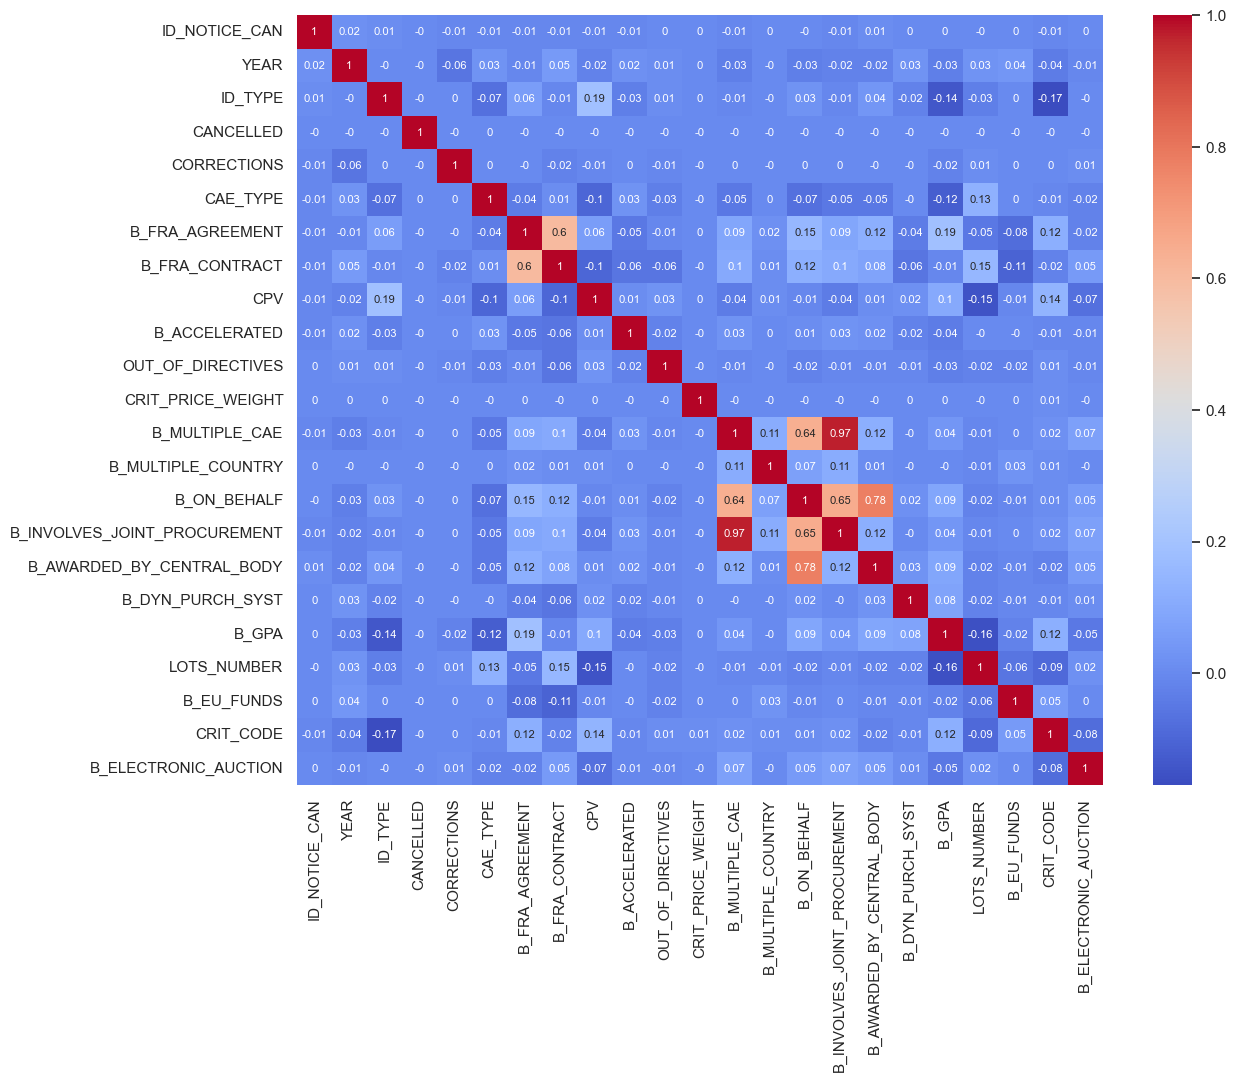

In [422]:
sns.set_theme(rc={"figure.figsize":(13, 10)})
sns.heatmap(round(df_non_null.corr(numeric_only=True), 2), cmap="coolwarm", annot=True, annot_kws={"size":8});